# **Aim**
So far, in this training, you have learnt to perform Power analysis attacks. There exists another class of attacks which exploits computational faults during the encryption/decryption to extract the secret key. This class of attacks, known as fault attacks (FA), has been exploited to break several practical applications. Controlled faults can be induced both in embedded devices and in remote cloud servers. There exist instances where FA is utilized for unauthorized upgradation of Xbox gaming consoles. Recently, FAs have been demonstrated on commercial X86-64 machines exploiting Row-Hammar bugs and power management logic. In the theory session, you have been introduced with an FA attack for accessing the data transferred through the CAN bus of modern automotive systems. The attacker extracts the secret key from the hardware security module (which runs AES) by means of FA.   

In the following assignment, you shall learn to perform FA on AES. Like the previous assignments, first, you shall simulate the faults and construct the attack on the simulated faulty ciphertexts. Finally, you shall be provided with faulty ciphertexts from real devices running hardware AES (similar to the CAN bus example). You shall be extracting some parts of the key from those ciphertexts.

# **Task-5: Fault Simulation and Differential Fault Analysis of AES-128**
AES is widely believed to be mathematically secure as no cryptanalysis effort has been reported till date, which is practical in terms of compuatational complexity. The best known result is the Biclique attack, which has a complexity of 2^126.1. However, with a **single fault** induced at the 8th round, the complexity of AES can be reduced to 2^8. An efficient implementation of this attack extracts the 128-bit key in minutes.

In this assignment, we shall use one variant of the 8th round FA on AES. To make it faster, we shall exploit two faulty ciphertexts.



# **Instructions**

# **Part 1: Fault Simulation**
In this assignment, you have to complete a fault simulator for AES-128, which induces random byte faults in the AES state.

1. Complete the function `inject_fault(state, byte_loc=0)`. Modify **line no. 14** to implement fault injection.

2. Uncomment **line no. 31 -- 35**.

3. Run the code. You shall be getting two correct ciphertexts and corresponding faulty ciphertexts.

In [ ]:
import math
import numpy as np
import scipy
import random
import csv
from aes import *


# Implement Fault injection
def inject_fault(state, byte_loc=0):
	for i in range(4):
		for j in range(4):
			if((i*4 + j) == byte_loc):
				state[j][i] = state[j][i]				# Modify here; Hint: Generate random integer within range (1,d) (d<=255)
											            # with the command (random.randint(1,d) & 0xff)
	return state

# Encryption module with fault injection simulation
def encrypt_faultsim(pt=None, inj_round=8, byte_loc=0):

	if pt is None:
		pt = [0x00, 0x11, 0x22, 0x33, 0x44, 0x55, 0x66, 0x77, 0x88, 0x99, 0xaa, 0xbb, 0xcc, 0xdd, 0xee, 0xff]
	for i in range(4):
		for j in range(4):
			cipher.state[j][i] = pt[i*4 + j]
	rnd = 0
	cipher.AddRoundKey(rnd)

	for rnd in range(1, cipher.Nr):
		# Fault injection ###########################
		# ENTER YOUR CODE HERE
		#############################################
		cipher.SubBytes()
		cipher.ShiftRows()
		cipher.MixColumns()
		cipher.AddRoundKey(rnd)
	cipher.SubBytes()
	cipher.ShiftRows()
	cipher.AddRoundKey(cipher.Nr)

	for i in range(4):
		for j in range(4):
			cipher.ciphertext[i*4 + j] = cipher.state[j][i]

	return cipher.ciphertext



# Parameters
no_faulty_ciphertexts = 2
inject_round = 8
byte_loc = 0


# Initialize
cipher = AES()
cipher.KeyExpansion()


correct_ct_list = []
faulty_ct_list = []

for i in range(no_faulty_ciphertexts):
	# Generate Random plaintext
	rand_pt = [random.randint(0,255) for x in range(16)]

	# Perform Correct execution
	correct = cipher.encrypt(pt=rand_pt)
	print("Correct Ciphertext %d:	"%(i+1), end=" ")
	print(correct)
	correct_ct_list.append(intarraytohexstring(correct))

	# Perform Faulty execution
	faulty = encrypt_faultsim(pt=rand_pt, inj_round=inject_round, byte_loc=byte_loc)
	print("Faulty Ciphertext %d:	"%(i+1), end=" ")
	print(faulty)
	faulty_ct_list.append(intarraytohexstring(faulty))
	print("")

In [ ]:
cipher.get_lastroundkey()

# **Part 2: Differential Fault Analysis**
In this part, you have to perform DFA with the correct and faulty ciphertexts obtained in the previous code cell. You shall be extracting 4 bytes (32 bits) of the last round key.

1. Please refer to the diagram below.

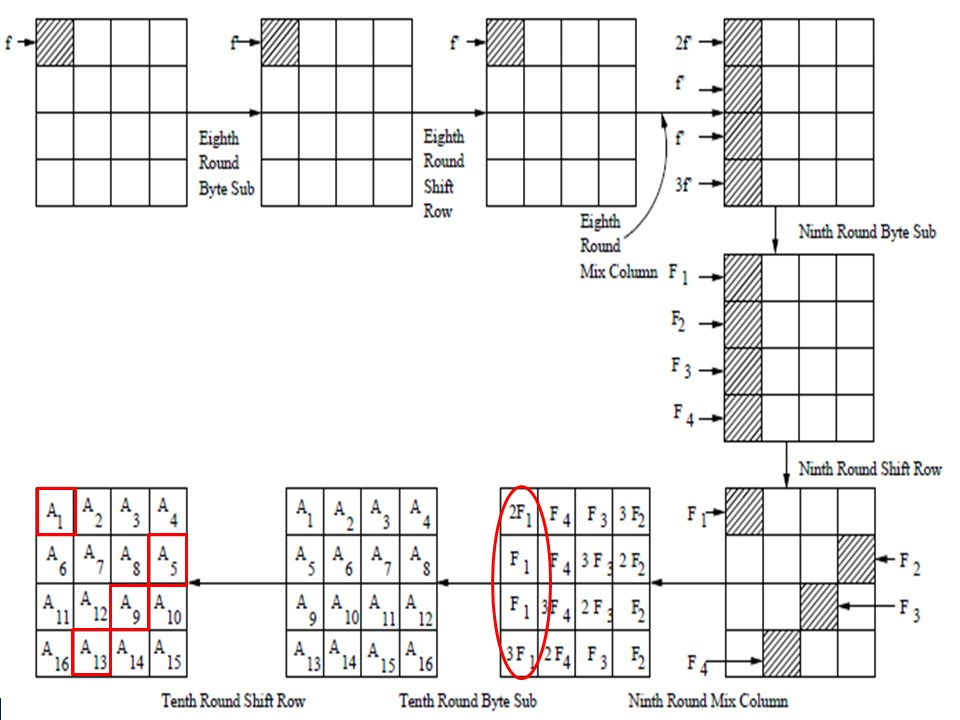


> The DFA attack begins with a pair of correct and faulty ciphertext. By guessing 4 bytes of secret key, it partially decrypts the ciphertexts up to the 3rd state from the end (ref. image). Only for a handful of secret key guesses, the differential at this state will have the pattern (2F1, F1, F1, 3F1). These are the candidate correct keys and are stored. Next, the same operation is performed on another pair of correct and faulty ciphertexts. The intersection between the two sets of candidate keys (obtained from two pairs) returns unique correct key (i.e. 4 bytes of it).


2. Please note that in the pattern (2F1, F1, F1, 3F1) the multiplications with 2 and 3 are performed in the finite field GF(2^8). It is not straightforrword to compute these multiplications. However, we have provided you with functions which perform these multiplications:


> a) `field_mul_2(x)`: Perform multiplication by 2 in GF(2^8).

> b) `field_mul_3(x)`: Perform multiplication by 3 in GF(2^8).

3. You have to complete the following code by inserting few lines (**line no. 82, 83, 88, 112**) .

4. Once done, copy the correct and faulty ciphertext pairs you have obtained in **line no. 48 -- 51** .

5. Run the code. You shall be getting 4 bytes of keys. You can also verify this!!! Run the next code block.

In [ ]:
"""
DFA on AES with 8th round fault injection and two faulty ciphertexts.
This code only finds out first 32-key bits and is used as a tutorial.
Modifications for full round key recovery is trivial, but requires
more computational effort.

Written by: Sayandeep Saha
"""
import numpy as np
import sys

# Your_code = 5

def xtime(x):
	tmp1 = x<<1
	tmp1 = tmp1&0xff
	tmp2 = x>>7
	tmp2 = tmp2&1
	tmp2 = tmp2*0x1b
	val = tmp1^tmp2
	return val

def field_mul_2(x):
	return xtime(x)

def field_mul_3(x):
	return xtime(x)^x


sbox_inv = [82,   9, 106, 213,  48,  54, 165,  56, 191,  64, 163, 158, 129, 243, 215, 251,
124, 227,  57, 130, 155,  47, 255, 135,  52, 142,  67,  68, 196, 222, 233, 203,
84, 123, 148,  50, 166, 194,  35,  61, 238,  76, 149,  11,  66, 250, 195,  78,
8,  46, 161, 102,  40, 217,  36, 178, 118,  91, 162,  73, 109, 139, 209,  37,
114, 248, 246, 100, 134, 104, 152,  22, 212, 164,  92, 204,  93, 101, 182, 146,
108, 112,  72,  80, 253, 237, 185, 218,  94,  21,  70,  87, 167, 141, 157, 132,
144, 216, 171,   0, 140, 188, 211,  10, 247, 228,  88,   5, 184, 179,  69,   6,
208,  44,  30, 143, 202,  63,  15,   2, 193, 175, 189,   3,   1,  19, 138, 107,
58, 145,  17,  65,  79, 103, 220, 234, 151, 242, 207, 206, 240, 180, 230, 115,
150, 172, 116,  34, 231, 173,  53, 133, 226, 249,  55, 232,  28, 117, 223, 110,
71, 241,  26, 113,  29,  41, 197, 137, 111, 183,  98,  14, 170,  24, 190,  27,
252,  86,  62,  75, 198, 210, 121,  32, 154, 219, 192, 254, 120, 205,  90, 244,
31, 221, 168,  51, 136,   7, 199,  49, 177,  18,  16,  89,  39, 128, 236,  95,
96,  81, 127, 169,  25, 181,  74,  13,  45, 229, 122, 159, 147, 201, 156, 239,
160, 224,  59,  77, 174,  42, 245, 176, 200, 235, 187,  60, 131,  83, 153,  97,
23,  43,   4, 126, 186, 119, 214,  38, 225, 105,  20,  99,  85,  33,  12, 125]


# -----------------------------------------------------------------------------------
# ENTER THE FAULTY AND CORRECT CIPHERTEXT PAIRS HERE
correct_ct_1 = [17, 123, 242, 230, 229, 233, 115, 118, 170, 208, 108, 248, 22, 142, 130, 165]	# Correct ciphertext 1
correct_ct_2 = [220, 119, 223, 90, 132, 193, 6, 118, 105, 240, 113, 210, 88, 119, 150, 160] # Correct ciphertext 2
faulty_ct_1 = [252, 139, 46, 228, 151, 44, 156, 46, 231, 18, 153, 90, 14, 25, 67, 183] # Faulty ciphertext 1
faulty_ct_2 = [232, 180, 153, 233, 111, 43, 230, 58, 46, 97, 135, 166, 149, 125, 64, 233]  # Faulty ciphertext 2
# -----------------------------------------------------------------------------------


# Associated data structures
correct_key_pool_1 = []
correct_key_pool_2 = []
correct_ct_1_state = np.zeros(shape = (4, 4), dtype='int')
correct_ct_2_state = np.zeros(shape = (4, 4), dtype='int')
faulty_ct_1_state = np.zeros(shape = (4, 4), dtype='int')
faulty_ct_2_state = np.zeros(shape = (4, 4), dtype='int')
round_key = np.zeros(shape = (4, 4), dtype='int')

# Create the state arrays
cnt = 0
for i in range(4):
	for j in range(4):
		correct_ct_1_state[j][i] = correct_ct_1[cnt]
		correct_ct_2_state[j][i] = correct_ct_2[cnt]
		faulty_ct_1_state[j][i] = faulty_ct_1[cnt]
		faulty_ct_2_state[j][i] = faulty_ct_2[cnt]
		cnt = cnt + 1



# Now, invert the ciphertexts and find the key

# Invert the first ciphertext and dump potential key candidates

cnt1 = 0
for fault in range(1, 256):
	for key_0 in range(0,256):
		t1=correct_ct_1_state[X][X]^key_0 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
		t2=faulty_ct_1_state[X][X]^key_0 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
		t1=t1&0xff
		t2=t2&0xff
		inv_t1=sbox_inv[t1]
		inv_t2=sbox_inv[t2]
		if((field_mul_2(fault))==((inv_t1^inv_t2)&0xff)):
			for key_1 in range(0,256):
				t1=correct_ct_1_state[X][X]^key_1 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
				t2=faulty_ct_1_state[X][X]^key_1 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
				t1=t1&0xff
				t2=t2&0xff
				inv_t1=sbox_inv[t1]
				inv_t2=sbox_inv[t2]
				if(fault==((inv_t1^inv_t2)&0xff)):
					for key_2 in range(0,256):
						t1=correct_ct_1_state[X][X]^key_2 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
						t2=faulty_ct_1_state[X][X]^key_2 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
						t1=t1&0xff
						t2=t2&0xff
						inv_t1=sbox_inv[t1]
						inv_t2=sbox_inv[t2]
						if(fault==((inv_t1^inv_t2)&0xff)):
							for key_3 in range(0, 256):
								t1=correct_ct_1_state[X][X]^key_3 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
								t2=faulty_ct_1_state[X][X]^key_3 #ENTER THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
								t1=t1&0xff
								t2=t2&0xff
								inv_t1=sbox_inv[t1]
								inv_t2=sbox_inv[t2]
								if((field_mul_3(fault))==((inv_t1^inv_t2)&0xff)):
									correct_key_pool_1.append((key_0, key_1, key_2, key_3))
									cnt1 = cnt1 + 1
                                    


# Invert the second ciphertext and dump potential key candidates
cnt2 = 0
for fault in range(1, 256):
	for key_0 in range(0,256):
		t1=correct_ct_2_state[X][X]^key_0 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
		t2=faulty_ct_2_state[X][X]^key_0 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
		t1=t1&0xff
		t2=t2&0xff
		inv_t1=sbox_inv[t1]
		inv_t2=sbox_inv[t2]
		if((field_mul_2(fault))==((inv_t1^inv_t2)&0xff)):
			for key_1 in range(0,256):
				t1=correct_ct_2_state[X][X]^key_1 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
				t2=faulty_ct_2_state[X][X]^key_1 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
				t1=t1&0xff 
				t2=t2&0xff
				inv_t1=sbox_inv[t1]
				inv_t2=sbox_inv[t2]
				if(fault==((inv_t1^inv_t2)&0xff)):
					for key_2 in range(0,256):
						t1=correct_ct_2_state[X][X]^key_2 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
						t2=faulty_ct_2_state[X][X]^key_2 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
						t1=t1&0xff
						t2=t2&0xff
						inv_t1=sbox_inv[t1]
						inv_t2=sbox_inv[t2]
						if(fault==((inv_t1^inv_t2)&0xff)):
							for key_3 in range(0, 256):
								t1=correct_ct_2_state[X][X]^key_3 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
								t2=faulty_ct_2_state[X][X]^key_3 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
								t1=t1&0xff
								t2=t2&0xff
								inv_t1=sbox_inv[t1]
								inv_t2=sbox_inv[t2]
								if((field_mul_3(fault))==((inv_t1^inv_t2)&0xff)):
									for i in range(cnt1):
										if ( (key_0 == correct_key_pool_1[i][0]) and (key_1 == correct_key_pool_1[i][1]) and (key_2 == correct_key_pool_1[i][2]) and (key_3 == correct_key_pool_1[i][3])):
											round_key[X][X] = key_0 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
											round_key[X][X] = key_1 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
											round_key[X][X] = key_2 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
											round_key[X][X] = key_3 #MODIFY THE CODE IN THIS LINE CHANGE THE 'X' TO CORRECT VALUE
									correct_key_pool_2.append((key_0, key_1, key_2, key_3))
									cnt2 = cnt2 + 1

np.set_printoptions(formatter={'int':hex})
print(round_key)

In [ ]:
for i in range(4):
    for j in range(4):
        print(int(round_key[j][i]), end = ", ")

# For your Reference

You need to get the last round key as mentioned below

In [ ]:
cipher.get_lastroundkey()

# **Verify**

In [ ]:
print(intarraytohexstring(cipher.get_lastroundkey()))

# TEST data

simulating faults for different key:

`Correct Ciphertext 1`:	 [4, 119, 58, 121, 224, 234, 189, 82, 89, 94, 133, 164, 41, 175, 134, 125]

`Faulty Ciphertext 1`:	 [6, 186, 203, 88, 173, 164, 25, 146, 227, 135, 220, 209, 225, 95, 105, 160]

`Correct Ciphertext 2`:	 [44, 76, 39, 50, 119, 245, 58, 239, 122, 105, 143, 48, 61, 45, 163, 83]

`Faulty Ciphertext 2`:	 [73, 218, 83, 175, 31, 242, 179, 213, 156, 205, 8, 163, 12, 31, 154, 225]

# You have to find the last round key for this data